In [18]:
import numpy as np
import pandas as pd
from src.dataset.clean import *
from src.features.process_features import *

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

# 0. Load the data + remove duplicate rows

In [19]:
dog_infos_raw = pd.read_csv("../data/raw/all_dog_infos.csv")
print("Shape before cleaning:", dog_infos_raw.shape)

dog_infos_raw = dog_infos_raw.drop_duplicates(subset=["dogId", "meetingId"], keep="first")
dog_infos_raw.reset_index(inplace=True,drop=True)
dog_infos_raw["raceDate"] = pd.to_datetime(dog_infos_raw["raceDate"], format="%d/%m/%Y")

print("Shape after cleaning:", dog_infos_raw.shape)

/var/folders/m_/00q0qn914cs98zd_8p4zlxmc0000gn/T/ipykernel_62793/3252163355.py:1: DtypeWarning: Columns (0: trapNumber) have mixed types. Specify dtype option on import or set low_memory=False.
  dog_infos_raw = pd.read_csv("../data/raw/all_dog_infos.csv")


Shape before cleaning: (3400585, 22)
Shape after cleaning: (3400576, 22)


# 1. Process numerical values

## 1.1 Replace outliers by NaN value

From notebook 2, we have observed that there are no missing values for some numerical columns like, "**trapNumber**", "**raceDistance**", etc...

All ID columns are not considered in the cleaning as there are no missing values and outliers don't apply.

Additionally, **resultSectionalTime** has many missing values that will be assessed later specifically. All the other columns are as of right now non-numerical columns.

We start by removing outliers so that we get clean stats to replace missing values.

In [20]:
numeric_cols = dog_infos_raw.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["dogId","meetingId","raceId","trapNumber","resultPosition",
                                                           "winnerOr2ndId","raceDistance","resultSectionalTime"]]

# Fill missing values for raceGoing and resultPosition with 0 and 3 respectively
dog_infos_raw.fillna({"raceGoing": 0}, inplace=True)
dog_infos_raw.fillna({"resultPosition": 3}, inplace=True)

# replace * in trapNumber with 3
dog_infos_raw['trapNumber'] = dog_infos_raw['trapNumber'].replace('*', 3)
dog_infos_raw['trapNumber'] = pd.to_numeric(dog_infos_raw['trapNumber'], errors='coerce')

dog_infos_raw = remove_outliers(dog_infos_raw, numeric_cols, k=2)

## 1.2 Replace missing by computed stats

Compute median race statistics per (*track*, *distance*, *class*) using fully observed rows, then merge these group-level stats back into the dataset and use them to fill missing values in **resultRunTime**, **resultAdjustedTime**, and **raceWinTime** (with optional global fallback).

In [21]:
cols_to_fill = ["resultRunTime","resultAdjustedTime","raceWinTime"]
group_cols = ['trackName','raceDistance','raceClass']

# mask of rows with full info
observed_mask = dog_infos_raw[cols_to_fill + group_cols].notna().all(axis=1)

# compute group medians (only numeric columns matter)
stats = (
    dog_infos_raw.loc[observed_mask]
    .groupby(group_cols)[cols_to_fill]
    .median()
    .reset_index()
)

# merge stats back
dog_infos_raw = dog_infos_raw.merge(
    stats,
    on=group_cols,
    how='left',
    suffixes=('', '_stat')
)

# fill missing values ONLY
for col in cols_to_fill:
    dog_infos_raw[col] = dog_infos_raw[col].fillna(dog_infos_raw[f"{col}_stat"])

# cleanup
dog_infos_raw.drop(columns=[f"{col}_stat" for col in cols_to_fill], inplace=True)

In [22]:
print("Columns processed:", cols_to_fill)

Columns processed: ['resultRunTime', 'resultAdjustedTime', 'raceWinTime']


## 1.3 Remove rows with resultPosition = 0

From observing the dataset, it seems that when you have `resultPosition`to 0, it means someting wrong is with the race itself. It doesn´t account for many of the races so we will remove them. 

In [23]:
dog_infos_raw = dog_infos_raw[dog_infos_raw['resultPosition'] != 0].reset_index(drop=True)

## 1.4 Replace the remaining missing values and outliers by the mean

In [24]:
dog_infos_raw = replace_outliers_with_mean_iqr(dog_infos_raw, numeric_cols, k=2)
print("Columns processed:", numeric_cols)

Columns processed: ['resultRunTime', 'resultDogWeight', 'resultAdjustedTime', 'raceGoing', 'raceWinTime']


Additionally, **resultBetweenDistance** has missing 1/6 values missing, comming from the distance put to NaN for winning dogs. So we will consider it after seperatly.

# 2. Process non-numerical columns

In [25]:
df_processed = dog_infos_raw.copy()

## 2.1 raceClass and raceTime

These two columns have only a very small amount of missing values, around **0.03%**. To keep the treatment simple and low-impact, we fill them with the most common value within each **trackName**, then use the global mode as a final fallback for any remaining rows.

In [26]:
raceclass_mode_by_track = df_processed.groupby("trackName")["raceClass"].agg(
    lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan
)
racetime_mode_by_track = df_processed.groupby("trackName")["raceTime"].agg(
    lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan
)

global_raceclass_mode = df_processed["raceClass"].mode(dropna=True).iloc[0]
global_racetime_mode = df_processed["raceTime"].mode(dropna=True).iloc[0]

df_processed["raceClass"] = df_processed["raceClass"].fillna(df_processed["trackName"].map(raceclass_mode_by_track))
df_processed["raceTime"] = df_processed["raceTime"].fillna(df_processed["trackName"].map(racetime_mode_by_track))

df_processed["raceClass"] = df_processed["raceClass"].fillna(global_raceclass_mode)
df_processed["raceTime"] = df_processed["raceTime"].fillna(global_racetime_mode)

print("raceClass mode fallback:", global_raceclass_mode)
print("raceTime mode fallback:", global_racetime_mode)
print(df_processed[["raceClass", "raceTime"]].isna().sum())

raceClass mode fallback: A5
raceTime mode fallback: 13:51:00
raceClass    0
raceTime     0
dtype: int64


## 2.2 SP column

The **SP** column is composed of strings that represent the market odds. We will split the string based on the "/", and output new columns: 

- **numeratorSP** and **denominatorSP**. 

We can later do the division if needed.

In [27]:
df_processed[["numeratorSP", "denominatorSP"]] = df_processed["SP"].apply(
    lambda x: pd.Series(get_SP_num_denom(x))
)

## 2.3 resultBtnDistance column

This column is either a direct value or a str like HD, NK, etc... We also have values for DNF or DIS. So we process to transform into numeric distance. 

In [28]:
df_processed["resultBtnDistance"] = df_processed["resultBtnDistance"].apply(parse_btn_distance)

## 2.4 resultComment column

In [29]:
remarks_df = pd.read_csv("../data/raw/doggos_values_remarks.csv", delimiter=";")
# Build dictionary: lowercase remark -> score
remark_score = dict(
    zip(
        remarks_df["Remark"].str.lower(),
        remarks_df["Score"]
    )
)

In [30]:
df_processed["commentScore"] = df_processed["resultComment"].apply(lambda x: score_result_comment(x, remark_score))

# 3. Final cleaning of columns

Here are the stats of the new processed columns. We remove outliers and missing values.

In [31]:
new_cols = ["numeratorSP", "denominatorSP" ,"resultBtnDistance", "commentScore"]
df_processed = replace_outliers_with_mean_iqr(df_processed, new_cols, k=2)

In [32]:
df_processed[new_cols].describe(), len(df_processed), df_processed[new_cols].isna().sum()

(        numeratorSP  denominatorSP  resultBtnDistance  commentScore
 count  3.383103e+06   3.383103e+06       3.383103e+06  3.383103e+06
 mean   6.625621e+00   1.675319e+00       2.979896e+00  1.148522e-01
 std    2.967520e+00   1.020526e+00       3.486790e+00  1.503885e+00
 min    1.000000e+00   1.000000e+00       0.000000e+00 -5.000000e+00
 25%    5.000000e+00   1.000000e+00       2.000000e-01 -1.000000e+00
 50%    6.000000e+00   1.000000e+00       1.500000e+00  0.000000e+00
 75%    9.000000e+00   2.000000e+00       3.750000e+00  1.000000e+00
 max    1.700000e+01   4.000000e+00       1.150000e+01  5.000000e+00,
 3383103,
 numeratorSP          0
 denominatorSP        0
 resultBtnDistance    0
 commentScore         0
 dtype: int64)

# 4. Results of outliers and missing values removal

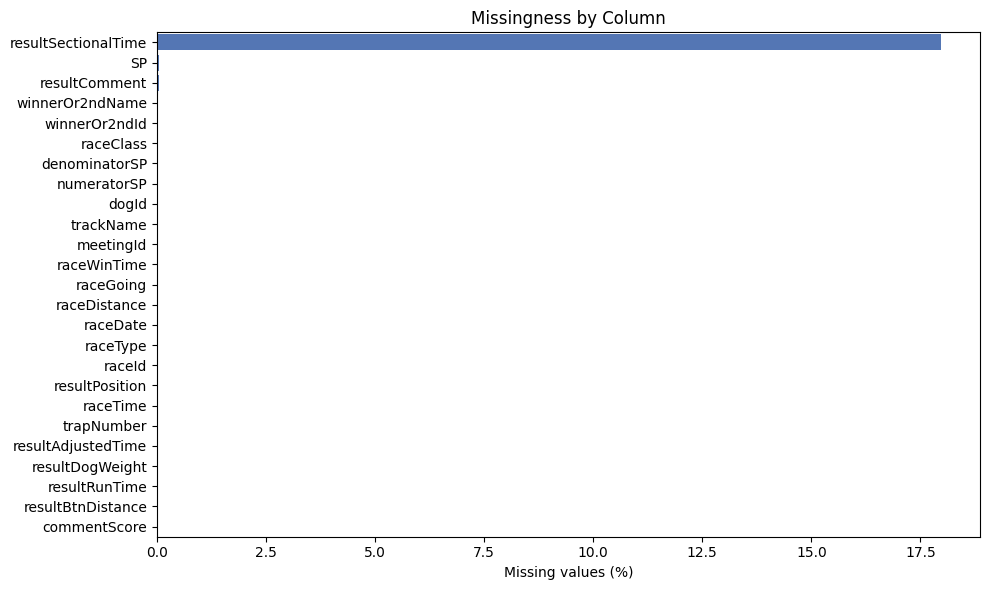

,missing_pct
resultSectionalTime,17.967529
SP,0.054417
resultComment,0.037214
winnerOr2ndName,0.005764
winnerOr2ndId,0.005764
raceClass,0.000000
denominatorSP,0.000000
numeratorSP,0.000000
dogId,0.000000
trackName,0.000000


In [33]:
missingness = (
    df_processed.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=missingness.reset_index(), x="missing_pct", y="index", color="#4472c4")
plt.title("Missingness by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

missingness

In [34]:
df_processed.describe()

,resultPosition,resultBtnDistance,resultSectionalTime,resultRunTime,resultDogWeight,winnerOr2ndId,resultAdjustedTime,trapNumber,raceDate,raceId,raceDistance,raceGoing,raceWinTime,meetingId,dogId,numeratorSP,denominatorSP,commentScore
count,3.383103e+06,3.383103e+06,2.775243e+06,3.383103e+06,3.383103e+06,3.382908e+06,3.383103e+06,3.383103e+06,3383103,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06,3.383103e+06
mean,3.434856e+00,2.979896e+00,5.036692e+00,2.869812e+01,2.996382e+01,5.115995e+05,2.868684e+01,3.478492e+00,2019-06-25 13:08:34.652378,5.369932e+05,4.455550e+02,-5.365590e-01,2.834907e+01,3.511598e+05,5.095508e+05,6.625621e+00,1.675319e+00,1.148522e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,2.353000e+01,1.910000e+01,7.440000e+02,2.357000e+01,1.000000e+00,2013-06-29 00:00:00,1.000000e+00,0.000000e+00,-5.000000e+01,2.329000e+01,2.756040e+05,7.440000e+02,1.000000e+00,1.000000e+00,-5.000000e+00
25%,2.000000e+00,2.000000e-01,3.850000e+00,2.831000e+01,2.720000e+01,4.600950e+05,2.833000e+01,2.000000e+00,2016-09-10 00:00:00,2.406570e+05,4.150000e+02,-1.000000e+01,2.799000e+01,3.172310e+05,4.582440e+05,5.000000e+00,1.000000e+00,-1.000000e+00
50%,3.000000e+00,1.500000e+00,4.470000e+00,2.876000e+01,2.980000e+01,5.038310e+05,2.875000e+01,3.000000e+00,2019-04-12 00:00:00,5.235380e+05,4.700000e+02,0.000000e+00,2.842000e+01,3.498910e+05,5.025150e+05,6.000000e+00,1.000000e+00,0.000000e+00
75%,5.000000e+00,3.750000e+00,5.100000e+00,2.986000e+01,3.260000e+01,5.487910e+05,2.984000e+01,5.000000e+00,2022-04-28 00:00:00,8.361660e+05,4.800000e+02,1.000000e+01,2.952000e+01,3.845740e+05,5.472590e+05,9.000000e+00,2.000000e+00,1.000000e+00
max,8.000000e+00,1.150000e+01,9.531000e+01,3.451000e+01,4.340000e+01,6.521660e+05,3.447000e+01,8.000000e+00,2025-04-03 00:00:00,1.119841e+06,1.048000e+03,5.000000e+01,3.409000e+01,4.277520e+05,6.521660e+05,1.700000e+01,4.000000e+00,5.000000e+00
std,1.684843e+00,3.486790e+00,2.880362e+00,1.855366e+00,3.395776e+00,6.857120e+04,1.840450e+00,1.705091e+00,NaN,3.381650e+05,8.502939e+01,1.593748e+01,1.849392e+00,3.998123e+04,6.855843e+04,2.967520e+00,1.020526e+00,1.503885e+00


In [35]:
df_processed.to_csv("../data/intermediate/03_dog_infos_processed.csv", index=False)

# 5. Summary of actions done

- resultPosition: filled missing values by 3, remove rows with resultPosition = 0

- resultBtnDistance: mapped the distance to a small value dictionnary and replaced the outliers by the mean

- resultSectionalTime: TO BE PROCESSED

- resultComment: mapped the string comments to values, replaced outliers by the mean

- resultDogWeight, raceDistance: replaced outliers by the mean

- resultRunTime, resultAdjustedTime, raceWinTime: replaced by the stats per race track, distance and race class

- raceClass, raceTime: filled the very rare missing values with the most common value per track, with a global mode fallback

- winnerOr2ndId, raceDate, raceId, meetingId: not filled missing values but there are very few and these will be issued if necessary later

- trapNumber: replaced "*" and missing values by 3

- raceGoing: filled missing values by 0
